# INVESTIGACIÓN: ALIASING Y MOIRÉ - NORMALIZACIÓN

## Conceptos
- **Aliasing**: Artefactos por muestreo insuficiente
- **Moiré**: Patrones ondulantes por interferencia
- **Solución**: Filtros combinados + kernel personalizado

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
print('✓ Librerías cargadas')

✓ Librerías cargadas


In [2]:
# Kernel Personalizado Combinado (ambas diagonales Sobel)
kernel_diagonal = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
kernel_diagonal_inv = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
kernel_combinado = np.abs(kernel_diagonal) + np.abs(kernel_diagonal_inv)
kernel_combinado = kernel_combinado / kernel_combinado.sum()

def unsharp_mask(img, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(img.astype(np.float32), (0, 0), sigma)
    resultado = img.astype(np.float32) + strength * (img.astype(np.float32) - blurred)
    return np.uint8(np.clip(resultado, 0, 255))

print('✓ Kernel y funciones listas')

✓ Kernel y funciones listas


---
# PARTE 1: NORMALIZACIÓN DE MOIRÉ
## Usando imagen MITSURI.jpg

In [3]:
# Cargar imagen MOIRÉ
img_moire = cv2.imread(r'd:\PDI26\pdi26\MITSURI.jpg', 0)
if img_moire is None:
    raise Exception('ERROR: MITSURI.jpg no encontrada')
print(f'✓ MITSURI.jpg cargada: {img_moire.shape}')

✓ MITSURI.jpg cargada: (736, 736)


In [4]:
# Aplicar kernel personalizado para DETECTAR moiré
kernel_detection = cv2.filter2D(img_moire.astype(np.float32), -1, kernel_combinado)
kernel_detection = np.uint8(np.clip(np.abs(kernel_detection), 0, 255))

# Procesar para ELIMINAR moiré
resultado_moire = cv2.bilateralFilter(img_moire, 7, 60, 60)
resultado_moire = cv2.medianBlur(resultado_moire, 5)
resultado_moire = cv2.GaussianBlur(resultado_moire, (7, 7), 2.0)
resultado_moire = unsharp_mask(resultado_moire, sigma=0.6, strength=0.5)

print('✓ Moiré procesado')

✓ Moiré procesado


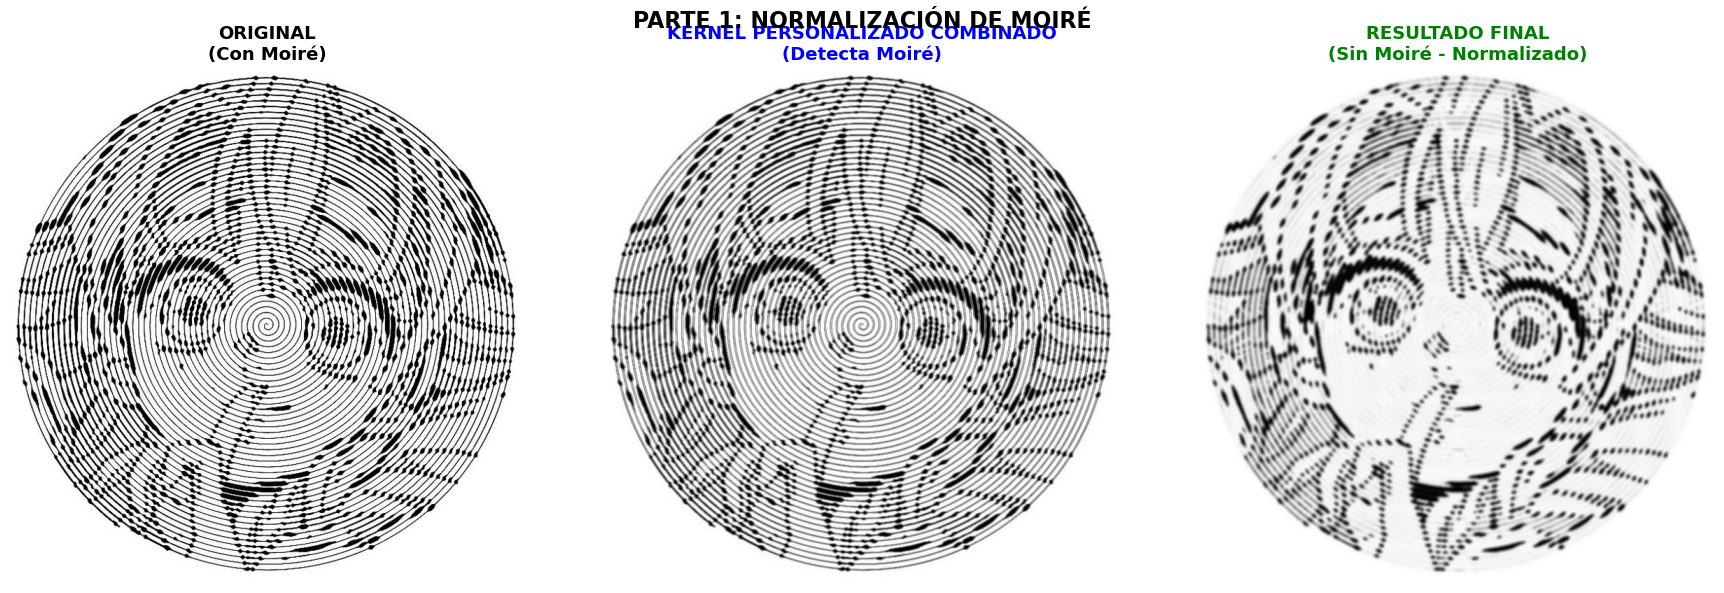

✓ Visualización completada


In [5]:
# VISUALIZAR: 3 IMÁGENES
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_moire, cmap='gray')
plt.title('ORIGINAL\n(Con Moiré)', fontsize=13, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel_detection, cmap='gray')
plt.title('KERNEL PERSONALIZADO COMBINADO\n(Detecta Moiré)', fontsize=13, fontweight='bold', color='blue')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resultado_moire, cmap='gray')
plt.title('RESULTADO FINAL\n(Sin Moiré - Normalizado)', fontsize=13, fontweight='bold', color='green')
plt.axis('off')

plt.suptitle('PARTE 1: NORMALIZACIÓN DE MOIRÉ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Visualización completada')

In [ ]:
# Guardar resultado
cv2.imwrite(r'd:\PDI26\pdi26\resultado_moire_normalizado.jpg', resultado_moire)
print('✓ Guardado: resultado_moire_normalizado.jpg')

---
# PARTE 2: NORMALIZACIÓN DE ALIASING
## Usando imagen Idols.jpg (o Moire1.jpg)

In [6]:
# Cargar imagen ALIASING
img_aliasing = cv2.imread(r'd:\PDI26\pdi26\Idols.jpg', 0)
if img_aliasing is None:
    # Intentar alternativa
    img_aliasing = cv2.imread(r'd:\PDI26\pdi26\Moire1.jpg', 0)
if img_aliasing is None:
    raise Exception('ERROR: Imagen de aliasing no encontrada. Verifica: Idols.jpg o Moire1.jpg')
print(f'✓ Imagen aliasing cargada: {img_aliasing.shape}')

✓ Imagen aliasing cargada: (736, 736)


In [7]:
# Procesar para ELIMINAR aliasing
resultado_aliasing = cv2.bilateralFilter(img_aliasing, 7, 60, 60)
resultado_aliasing = cv2.medianBlur(resultado_aliasing, 5)
resultado_aliasing = cv2.GaussianBlur(resultado_aliasing, (7, 7), 2.0)
resultado_aliasing = unsharp_mask(resultado_aliasing, sigma=0.6, strength=0.5)

print('✓ Aliasing procesado')

✓ Aliasing procesado


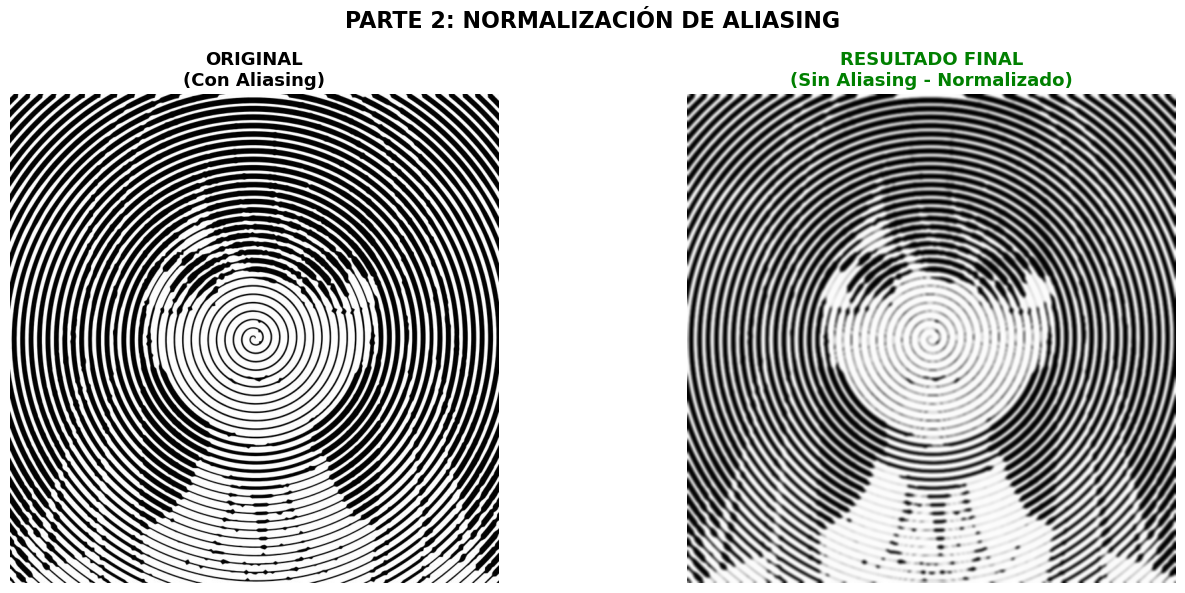

✓ Visualización completada


In [8]:
# VISUALIZAR: 2 IMÁGENES
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_aliasing, cmap='gray')
plt.title('ORIGINAL\n(Con Aliasing)', fontsize=13, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado_aliasing, cmap='gray')
plt.title('RESULTADO FINAL\n(Sin Aliasing - Normalizado)', fontsize=13, fontweight='bold', color='green')
plt.axis('off')

plt.suptitle('PARTE 2: NORMALIZACIÓN DE ALIASING', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Visualización completada')

In [ ]:
# Guardar resultado
cv2.imwrite(r'd:\PDI26\pdi26\resultado_aliasing_normalizado.jpg', resultado_aliasing)
print('✓ Guardado: resultado_aliasing_normalizado.jpg')
print('\n✓✓✓ TRABAJO COMPLETADO ✓✓✓')